# Hello SAFIRE
---

<font size="5"><b>Goal:</b>
At the end of this tutorial, you will know how to run an AFQMC calculation using SAFIRE and extract the AFQMC energy from the output
given all necessary inputs.
</font>

## What you will learn

---

<font size="4">

1. what the inputs and outputs of SAFIRE are and what their high level purposes are
2. how to invoke the SAFIRE executable from the command line in serial, using MPI, and using GPU(s)
3. how to extract the AFQMC energy from the outputs of SAFIRE using afqmctools
4. how to use the tutorial helper functions to do 2 and 3 from within an interactive Python notebook

</font>


&nbsp;




<font size="5"><b>
Inputs and outputs of SAFIRE.
</b>
</font>

---

<font size="4">

For this tutorial, we provide all of the inputs needed to run an AFQMC calculation.
You can find them in "files" relative to the
directory of this tutorial.

AFQMC is formulated in terms of a generic second quantized Hamiltonian and trial wavefunction.
In order to take advantage of this flexibility, SAFIRE accepts a generic
second quantized Hamiltonian and wavefunction, saved in HDF5 files, as input along with
AFQMC algorithmic parameters in a json-based input file.

Below is a schematic of the inputs and outputs of SAFIRE.

&nbsp;

<!---
<div>
<img src="./figs/inputs_and_outputs_all.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_all.png" width="800">
</div>



&nbsp;
&nbsp;

**We will learn more about the details of all of these files in future tutorials.**
For now, we will explain the purpose of each of these files at a high level
without going into the details.



&nbsp;

<font size="5">
<b>The Inputs
</b>
</font>

---

&nbsp;

<font size="4">
<b> Hamiltonian file : "hamil.h5"
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_hamil.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_hamil.png" width="800">
</div>



&nbsp;

An HDF5 file containing the second-quantized Hamiltonian $\hat{H}$. As we will see later, the json input file is used to select a Hamiltonian in a calculation.

We will learn how to generate this file in later tutorials.
For this tutorial, we have supplied an HDF5 file containing the Hamiltonian
corresponding to the Hubbard model on a 4x4 lattice with periodic boundary conditions,
and $U/t = 4$ in "hamil.h5".

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/models/Hubbard_4x4_tutorial.png" width="500">
</div>


&nbsp;
&nbsp;

For technical details on the hamiltonian HDF5 format, see [the User Guide](https://users.flatironinstitute.org/~beskridge/safire/user_manual/hamiltonians.html#lattice-model-hamiltonian).

&nbsp;
&nbsp;
&nbsp;

<font size="4">
<b> Wavefunction file : "wfn.h5"
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_wfn.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_wfn.png" width="800">
</div>

&nbsp;

An HDF5 file containing the trial wavefunction, $| \Psi_T \rangle$. As we will see later, the json input file is used to select a trial wavefunction in a calculation.



We will learn how to generate this file in later tutorials.
For this tutorial, we have supplied an HDF5 file containing the RHF
ground state as the trial wavefunction.

$$
| \Psi_T \rangle = | \Phi_{RHF} \rangle
$$

For technical details on the wavefunction HDF5 format, see [the User Guide](http://users.flatironinstitute.org/~beskridge/safire/user_manual/wavefunctions.html).

&nbsp;
&nbsp;

<font size="4">
<b> Input file (json format) : "input.json"
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_json.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_json.png" width="800">
</div>


&nbsp;

**We will learn about the input file in more detail in the next tutorial,
["Understanding the input file"](../02_input_file/input_file.html).**
For now, we provide just the details you need to understand this tutorial.

The json input file is used to set AFQMC run parameters,
and to tell SAFIRE where to find the trial wavefunction and Hamiltonian.
 The input file is organized into a hierarchy of input "blocks" which each control specific
details of the calculation.

**For now, you only need to understand the "wavefunction" and the "hamiltonian" input blocks.**
The "wavefunction" input block is used to tell SAFIRE where to find the HDF5 file containing the trial wavefunction.
Similarly, the "hamiltonian" input block is used to tell SAFIRE where to find the HDF5 file containing the Hamiltonian.  

The sample json file that we have provided is reproduced here.

```json
{
"afqmc": {
  "project": {
    "id": "qmc",
    "series": 0
  },
  "execute": {
    "walker_set": {
      "walker_type": "CLOSED"
    },
    "wavefunction": {
      "filename": "files/wfn.h5"
    },
    "hamiltonian": {
      "filename": "files/hamil.h5"
    },
    "timestep": 0.01,
    "steps": 10000,
    "n_walkers_per_mpi_task": 200,
    "seed": 42
  }
}
}
```
  
Notice that the "wavefunction" and "hamiltonian" input blocks point to the HDF5 file where we have saved the RHF ground
state and second quantized Hamiltonian, respectively.



&nbsp;
&nbsp;
&nbsp;

<font size="5">
<b>The Outputs
</b>
</font>

Now that we have seen what the inputs of SAFIRE are, we move on to what it outputs.

---


&nbsp;
&nbsp;

<font size="4">
<b> stdout
</b>
</font>

---

SAFIRE prints information about the setup of the AFQMC calculation to stdout along with timing information at the end.

We will see the output from SAFIRE throughout the tutorials. Here is a sample header which is printed at the beginning of
the output.

&nbsp;

```log
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
app git branch: develop
app git commit: 6a251b811061707f9dceb3804e146148bf58e90f
 AFQMCFactory Project settings:
    -- mixed_precision: false
    -- ncores (local) : 1
    -- n_groups       : 1
    -- id             : qmc
    -- series         : 0
    -- MPI tasks/node : 1
    -- MPI nodes      : 1
    -- MPI tasks      : 1
```


&nbsp;

You can see git information from when SAFIRE was compiled.
You can also see MPI / parallelization information.
We will explore the output further in later tutorials.

&nbsp;
&nbsp;
&nbsp;

<font size="4">
<b> scalar data file : [id].s[series].scalar.dat
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_scalar.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_scalar.png" width="800">
</div>



&nbsp;

A text-based file where stochastic samples of scalar data, such as the energy are printed by SAFIRE.

This file is not meant to be directly read by the user.
Instead, afqmctools provides tools to extract information from this file.
**We will learn how to extract the AFQMC energy from this file later in this tutorial.**

The name of file comes from the "id" and "series" parameters set in the json input file.
"id" is just some sting, and "series" is an integer.
They are used so that multiple AFQMC calculations can be performed in a single directory without
output file collisions.

&nbsp;
&nbsp;
&nbsp;

<font size="4">
<b> observables output HDF5 file : [id].s[series].stat.h5
</b>
</font>

---

&nbsp;

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_hdf5.png" width="800">
</div>




&nbsp;

An HDF5 file where stochastic samples of non-scalar data, such as the one-body reduced density matrix, are printed by SAFIRE
when requested.

Similarly to the [id].s[series].scalar.dat file, this file is not meant to be directly read by a user.
Instead, afqmctools provides tools to extract data from this file for you.
You will learn more about this in the [Estimators and post-processing tutorial](../04_using_estimators/04_using_estimators.html).

&nbsp;
&nbsp;
&nbsp;
</font>




## Running SAFIRE

---

<font size="4">

Now that we have learned what the inputs and outputs of SAFIRE are,
we are ready to learn how to run the SAFIRE executable given the inputs.

### Running SAFIRE in serial

SAFIRE can be invoked from the command line as
</font>

```bash
    $ /path/to/SAFIRE/build/bin/safire input.json
```
<font size="4">

where `input.json` is the json input file.
The input file can be called whatever you would like, so
long as its name ends in .json.
When you run this, an AFQMC calculation will be performed based on the contents of input.json,
using the Hamiltonian and trial wavefunction specified there.

&nbsp;

**For brevity, we will abreviate `/path/to/SAFIRE/build/bin/safire` as `safire` in this tutorial**.
There are many standard ways to make `safire` accessible from the command line in this way.

&nbsp;

You can see the possible command line options for SAFIRE by using the `-h`/`--help` switch.
</font>

&nbsp;

```bash
  $ safire --help

  SAFIRE
  Usage:
    /mnt/home/beskridge/software/SAFIRE/build/CPU/bin/safire [OPTION...] [optional args]

    -h, --help           print help message
    -v, --version        print version message
        --verbosity arg  0, 1, 2, ...: higher means more (default: 2)
        --debug arg      0, 1, 2, ...: higher means more (default: 0)
        --filenames arg  input filenames
```
<font size="4">

&nbsp;


### Exercise: Try Running SAFIRE

---

<font size="4">

Run SAFIRE with the provided input files.
You may use either the code block below, or run SAFIRE in a terminal
as described previously.
In either case, you can find the json input file here

```bash
   /path/to/SAFIRE/tutorials/lattices/01_hello_safire/files/input.json
```

&nbsp;

where `/path/to/SAFIRE` should be replaced with the path where
you have installed SAFIRE.

**The provided json input file assumes that you are running SAFIRE from
`/path/to/SAFIRE/tutorials/01_hello_safire/`**

After running with the default parameters, try changing the verbosity level to
see what changes.

<div class="alert alert-block alert-info">
<b>Note:</b>
    in a jupyter notebook, the `!` symbol will run commands in
    a shell instead of in Python.
</div>

</font>


In [ ]:
!safire files/input.json --verbosity 1

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
app git branch: develop
app git commit: 6a251b811061707f9dceb3804e146148bf58e90f
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 1 
    -- MPI nodes      : 1 
    -- MPI tasks      : 1 



****************************************************
*****************

### Post-excercise

---

You should the following a the top of the
output after running SAFIRE.

```log
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
app git branch: develop
app git commit: 6a251b811061707f9dceb3804e146148bf58e90f
 AFQMCFactory Project settings:
    -- mixed_precision: false
    -- ncores (local) : 1
    -- n_groups       : 1
    -- id             : qmc
    -- series         : 0
    -- MPI tasks/node : 1
    -- MPI nodes      : 1
    -- MPI tasks      : 1
```

&nbsp;

<font size="4">
Congratulations, you have now run an AFQMC calculation using SAFIRE!
In the directory that you ran this notebook from, you should see a file called
`qmc.s000.scalar.dat`.
We will return to how to use the tools in `afqmctools` to extract the AFQMC energy later in this tutorial.
</font>

&nbsp;



## Running SAFIRE in parallel

---

&nbsp;

### Using MPI

---

SAFIRE can be run with MPI in the usual ways.
For example, using mpirun, we could run SAFIRE with 64 MPI tasks as

```bash
    $ mpirun -np 64 safire --filenames input.json
```

It is important to note that the number of walkers is specified in the input file
as `n_walkers_per_mpi_task`.
So, the total number of walkers using the sample input file above and 64 MPI tasks
would be

$$
N_{walkers} = n_{walkers\_per\_mpi} * n_{mpi\_task} = 200 * 64 = 12800
$$.

For the sample inputs, this is significantly more walkers than is necessary,
and for calculations that run on a CPU only build of SAFIRE,
`n_walkers_per_mpi_task` will typically be on the order of 10-50.

&nbsp;

### GPU Builds

---

To run on GPUs, you must compile SAFIRE for the GPU. See the [documentation](https://users.flatironinstitute.org/~beskridge/safire/installation.html) for instructions on compiling for GPU.

On GPU builds of SAFIRE, the calculation is more efficient when
the GPU is saturated.
The specific number of walkers needed to achieve this depends on how large the system is.
For small systems, this could mean using on the order of 1000 walkers or more per task.
For very large systems, this may mean on the order of 10 walkers per MPI task.

&nbsp;

### Your Turn

---

Try running SAFIRE with MPI! To get the same numbers as us, you will need to use the same number of MPI processes as we did, 16.


In [ ]:
!mpirun -np 16 safire files/input.json --verbosity 1

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
app git branch: develop
app git commit: 6a251b811061707f9dceb3804e146148bf58e90f
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 16 
    -- MPI nodes      : 1 
    -- MPI tasks      : 16 



****************************************************
***************

## Basic post-processing

---

Now that we've learned how to invoke the SAIFRE executable from the command line in serial, using MPI, and using GPU(s),
we are ready to learn how to extract the AFQMC energy from the outputs of SAIFRE using afqmctools.

We previously ran SAIFRE on the Hamiltonian of the Hubbard model on a 4x4 lattice with periodic boundary conditions
and $U/t = 4$, and using a UHF trial wavefunction.
This generated a scalar data file, "qmc.s000.scalar.dat", which contains
the scalar data that was accumulated during the AFQMC calculation, including the AFQMC energy.

afqmctools provides the energy_stats CLI tool to extract data from the scalar data file.
If you followed the official installation instructions for `afqmctools`, you
should be able to run `$ energy_stats` from within whatever Python environment you
installed afqmctools in.

By default, `energy_stats` will compute the average AFQMC energy and the stochastic uncertainty of the
energy based on the samples in the `*.scalar.dat` file.
Below is an example of using `energy_stats` where we have set the "x axis" to "time",
and the equilibration "time" to 5.0 inverse energy units.

```bash
$ scalar_stats qmc.s000.scalar.dat -s time -e 2.0

====== [analyze_scalar_data Settings] ======

[+] fname            = qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 2.0             
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] ndiscard         = None            
[+] list             = False           
[+] trace            = False           
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] verbose          = True            
[+] autocorr         = None            
[+] savefig          = None            
[+] dump_avail_columns = False           

AFQMC Energy   -19.580848 +/-   0.000669 3.56  2.0/100.0
```

You can also view the AFQMC energy versus the total projection time (sometimes referred to as the "equilibration curve" by
adding the `-t` option to plot the data "trace".

Running

```bash
$ energy_stats qmc.s000.scalar.dat -x time -e 2.0 -t
```

will generate the plot,

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/models/Equil_hubbard_4x4_U4_hello_safire.png" width="800">
</div>



One should check the equlibration curve to ensure that the the equilibration
time, `-x time -e 2.0` is large enough to discard the samples where AFQMC is not
sampling from the target many-body wavefunction yet.
On the other hand, the equilibration length should not be so large that it discards
equilbrated samples.

We will learn how to post-process AFQMC results from SAFIRE
in more detail in the ["Post processing"](../03_post_processing/post_processing.html) Tutorial.

&nbsp;

### Exercise: Try Running energy_stats

---

<font size="4">

Use the code block below to run energy_stats on the data that we generated
in the last exercise.
You should get an AFQMC energy of `-19.580880 +/-   0.000697`
if you did not change any settings.

Now, try to changing the equilbration length such that only un-equilibrated samples
are discarded.

</font>

In [ ]:
!scalar_stats qmc.s000.scalar.dat -s time -e 2.0



====== [analyze_scalar_data Settings] ======

[+] fname            = qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 2.0             
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] ndiscard         = None            
[+] list             = False           
[+] trace            = False           
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] verbose          = True            
[+] autocorr         = None            
[+] savefig          = None            
[+] dump_avail_columns = False           

AFQMC Energy   -19.580848 +/-   0.000669 3.56  2.0/100.0


&nbsp;

## Post Exercise

---

If you play around with the equilbration length, you will see that, for very small equilibration length,
the predicted energy will be incorrect.
This is due to the inclusion of un-equilibrated samples in the average.
On the other hand, the average energy should be stable if you use too large of a value for the equilibration length.

&nbsp;

## Some Tutorial Helper Python Functions

---

Now that we have learned how to extract the AFQMC energy from the outputs of SAFIRE using afqmctools,
we are ready to how to use the tutorial helper functions to invoke SAFIRE and extract the AFQMC energy
from within an interactive Python notebook.

For convenience, we provide two helper functions in the `tutorials_utils` Python package.

1. The `run_afqmc()` function runs the SAFIRE executable in one of the several ways that
we described previously, depending on the `run_mode` parameter.
2. the `get_scratch_dir()` function, will generate a scratch directory and return a Path pointing to the scratch directory.

Together, these functions make it possible to complete the tutorials without leaving the interactive Python notebooks.
We explain each function below.

&nbsp;


### get_scratch_dir()

---

`get_scratch_dir()` will return a reference to the Path of a scratch directory that you get to set.
By default, it will create the directory if it does not already exits.
You can either specify the full path to the scratch directory as,

```python
    from tutorial_utils import get_scratch_dir
    scratch_dir = get_scratch_dir('/path/to/my/scratch/hello_safire')
```

or, you can pass a scratch root directory and scratch directory name as

```python
    from tutorial_utils import get_scratch_dir
    scratch_dir = get_scratch_dir('hello_safire', root_dir='/path/to/my/scratch/')
```

You can tell `get_scratch_dir()` to not attempt to create the directory with

```python
    from tutorial_utils import get_scratch_dir
    scratch_dir = get_scratch_dir('/path/to/my/scratch/hello_safire',create=False)
```

&nbsp;





### The run AFQMC convenince function

---

`run_afqmc(input_file=input_file, np=np)` runs the SAFIRE executable as

```bash
    $ mpirun -np [np] safire --filenames [input_file]
```

<div class="alert alert-block alert-warning">
<b>CAUTION:</b>
    The AFQMC_EXEC environment variable must be set to the path to the SAFIRE executable
    in order to use `run_afqmc()`.
</div>

Here is a typical example of using `run_afqmc()`.

```python
    from tutorial_utils import run_afqmc, get_scratch_dir

    scratch_dir = get_scratch_dir('/path/to/my/scratch/hello_safire')
    
    run_afqmc(
        run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there
        input_file="/path/to/inputfile/input.json",
        np=12,                              # number of MPI tasks
        output_file=None                    # optionally direct output to file; if None,
    )                                       # then output will be captured in the jupyter notebook.
```

Where the `np` parameter is forwarded directly to `-np [np]` and
`input_file` is passed to `qmcapp --filenames [input_file]`.

<div class="alert alert-block alert-info">
<b>Note:</b>
    There is no difference between running SAFIRE via `run_afqmc()` or
    directly in the command line other than convenience.
</div>

&nbsp;


### (afqmctools) the analyze scalar data function

---

The same functionality as `$ energy_stats`, from `afqmctools`, can
be accessed directly in a Python script via the `analyze_scalar_data()` function.
This is a standard component of `afqmctools`, and not just a part of these tutorials.

For convenience, we will favor the use of `analyze_scalar_data()` within interactive Python
notebooks; however, this is invoking exactly the same code as using `$ energy_stats` from
the CLI.
`energy_stats` can generate plots of the data, both from the CLI and from within Python.
We will make use of this feature during the tutorials to visualize the results.

&nbsp;


### Exercise: Run the full sample calculation using the convenience wrappers.

---

<font size="4">

Use the code block below to run the entire calculation again.

Just as before, at the end, you should get an AFQMC energy of `-19.580880 +/-   0.000697`
if you did not change any settings.
</font>

<div class="alert alert-block alert-info">
<b>Note:</b>
    The python `Path` class from `pathlib`, which is a part of the standard cPython distribution,
    greatly simplifies the process of specifying, and creating directories. We recommend using it
    in these tutorials. See the code block below!
</div>



Running AFQMC locally with 16 mpi tasks
AFQMC ran in 51.067304 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/hello_auxiliary_fields/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -19.580880 +/-   0.000697 3.77  5.0/100.0


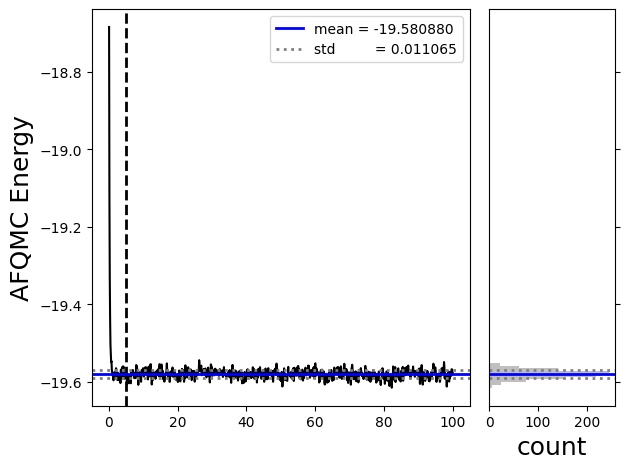

In [ ]:
from pathlib import Path
import shutil

import numpy as np

from afqmctools.hamiltonian.mol import write_hamiltonian_generic
from afqmctools.wavefunction.mol import write_wfn
from afqmctools.inputs.from_hdf import write_json
from tutorial_utils import run_afqmc, get_scratch_dir
from stats.scalar_dat import analyze_scalar_data

# For you TODO: set a scratch directory for the files that will be generated
home = Path.home()
scratch_dir = get_scratch_dir("hello_safire",home / ".scratch")

# copy the provided files
files_dir = scratch_dir / "files"
files_dir.mkdir(exist_ok=True)
shutil.copy("files/input.json", scratch_dir / "files" )
shutil.copy("files/hamil.h5", scratch_dir / "files" )
shutil.copy("files/wfn.h5", scratch_dir / "files" )

run_afqmc(
    run_dir=scratch_dir,
    input_file="files/input.json",   # the location of the sample input file.
    np=16,                                         # to run in serial just as before!
)

# post process!
_ = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    xaxis = "time",
    nequil = 5,
    trace = True
))

&nbsp;

## Summary

---


<font size="4">


In this tutorial, you learned

1. what the inputs and outputs of SAFIRE are and what their high level purposes are
2. how to invoke the SAFIRE executable from the command line in serial, using MPI, and using GPU(s)
3. how to extract the AFQMC energy from the outputs of SAFIRE using afqmctools
4. how to use the tutorial helper functions to do 2 and 3 from within an interactive Python notebook

Next, you learn more about the input file in ["Understanding the input file"](../02_understanding_the_input_file/02_understanding_the_input_file.html).

</font>
